# Assignment 7 - Graph drawing and network analysis

An important step to gain insight from data is to recognize existing, known structure and incorporate it into your analysis.
Graph structures as a mathematical representation of connectedness can be found in a wide variety of practical settings.

In this assignment we hope to enable you to:

* Understand what graphs are and how to recognize graph-type relationships in your data
* Use standard graph analysis techniques and tools to get answers for data analysis questions
* Work with large graphs on a desktop machine using the [graph-tool python library](https://graph-tool.skewed.de/)

## Background on graphs and a tool tutorial

If you require an introduction to basic graph notions, see Maël Fabien
's blog post [section I](https://maelfabien.github.io/machinelearning/graph_1/) and [section II](https://maelfabien.github.io/machinelearning/graph_2/) .
While graph theory and algorithms can involve deep mathematical connections, 
the basic definitions and much practical use of graph data is not difficult to get started with.

For further background on `graph-tool` refer to the [graph tutorial slides](https://stevenbergner.github.io/Teaching/cmpt767/graph-tutorial) and the [tutorial notebook](graph-tool-tutorial.ipynb).
See the [lab setup](#Environment-setup-details) on how you can use graph tool on the lab machines.

In [1]:
# Use this code for basic setup

import matplotlib as mpl
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Markdown
%matplotlib inline

import graph_tool.all as gt
print("graph-tool version: {}".format(gt.__version__.split(' ')[0]))

import gt_utils as au

graph-tool version: 2.59


/usr/shared/CMPT/big-data/condaenv/nn11-deactivated/lib/python3.11/site-packages/graph_tool/draw/cairo_draw.py:1544: RuntimeWarning: Error importing Gtk module: ; GTK+ drawing will not work.
  warnings.warn(msg, RuntimeWarning)


# Problem 1: Power grid analysis

In [2]:
g = gt.collection.data['power']
display(Markdown(gt.collection.descriptions['power']))

Power grid: An undirected, unweighted network representing the topology of the Western States Power Grid of the United States. Data compiled by D. Watts and S. Strogatz and made available on the web `here <http://cdg.columbia.edu/cdg/datasets>`_. Please cite D. J. Watts and S. H. Strogatz, Nature 393, 440-442 (1998). Retrieved from `Mark Newman's website <http://www-personal.umich.edu/~mejn/netdata/>`_.

 In this graph, an edge represents a power supply line. A node is either a generator, a transformator, or a substation.
 
**Task 1a**: Create a drawing of this graph that emphasizes nodes that have more than 10 incident (or incoming) power supply lines. Set the size of all other nodes to 0, but retain visibility of the power lines.

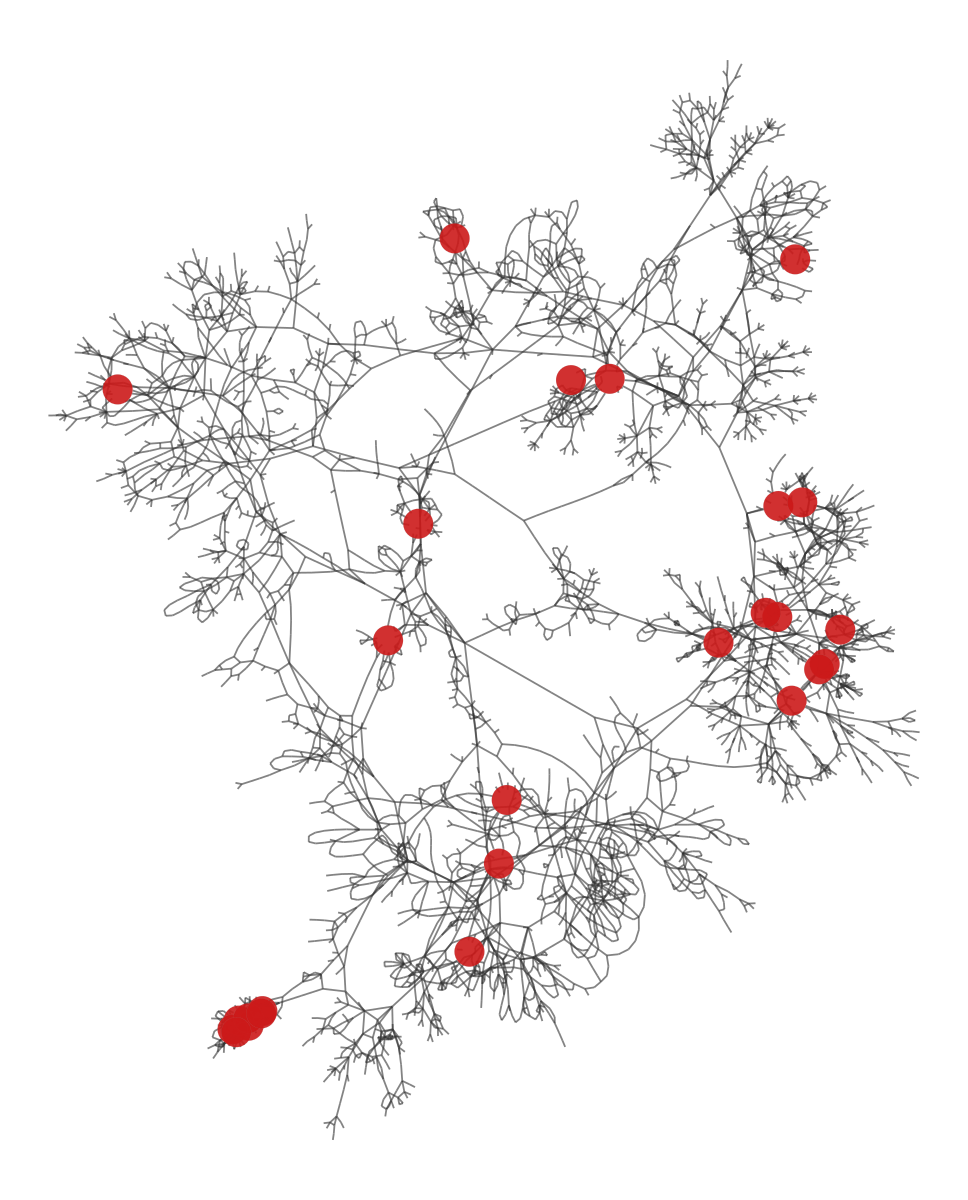

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7ab11a51e2d0, at 0x7ab1183f5050>

In [8]:
# Treat the graph as undirected (ignore edge direction)
ug = gt.GraphView(g, directed=False)

# Compute degree (number of connected power lines) for each node
deg = ug.degree_property_map("total")

# Create a vertex property to control node size
size = ug.new_vertex_property("double")

# Set node size:
# If a node has more than 10 connections → make it visible and large
# Otherwise → hide it by setting size to 0
for v in ug.vertices():
    if deg[v] > 10:
        size[v] = 15   # important node (hub)
    else:
        size[v] = 0    # hide small nodes

# Compute node positions for drawing
pos = gt.sfdp_layout(ug)

# Draw the graph
gt.graph_draw(
    ug,
    pos=pos,
    vertex_size=size,                    # control node size
    vertex_fill_color=[0.8, 0.1, 0.1, 0.9],  # red nodes
    edge_color=[0.2, 0.2, 0.2, 0.6],          # gray edges
    edge_pen_width=0.9
)

**Task 1b:** Identify one of the centrality measures that can be used to indicate powerlines that act as a bridge between different parts of the network. Use this to emphasize structurally important nodes and powerlines.

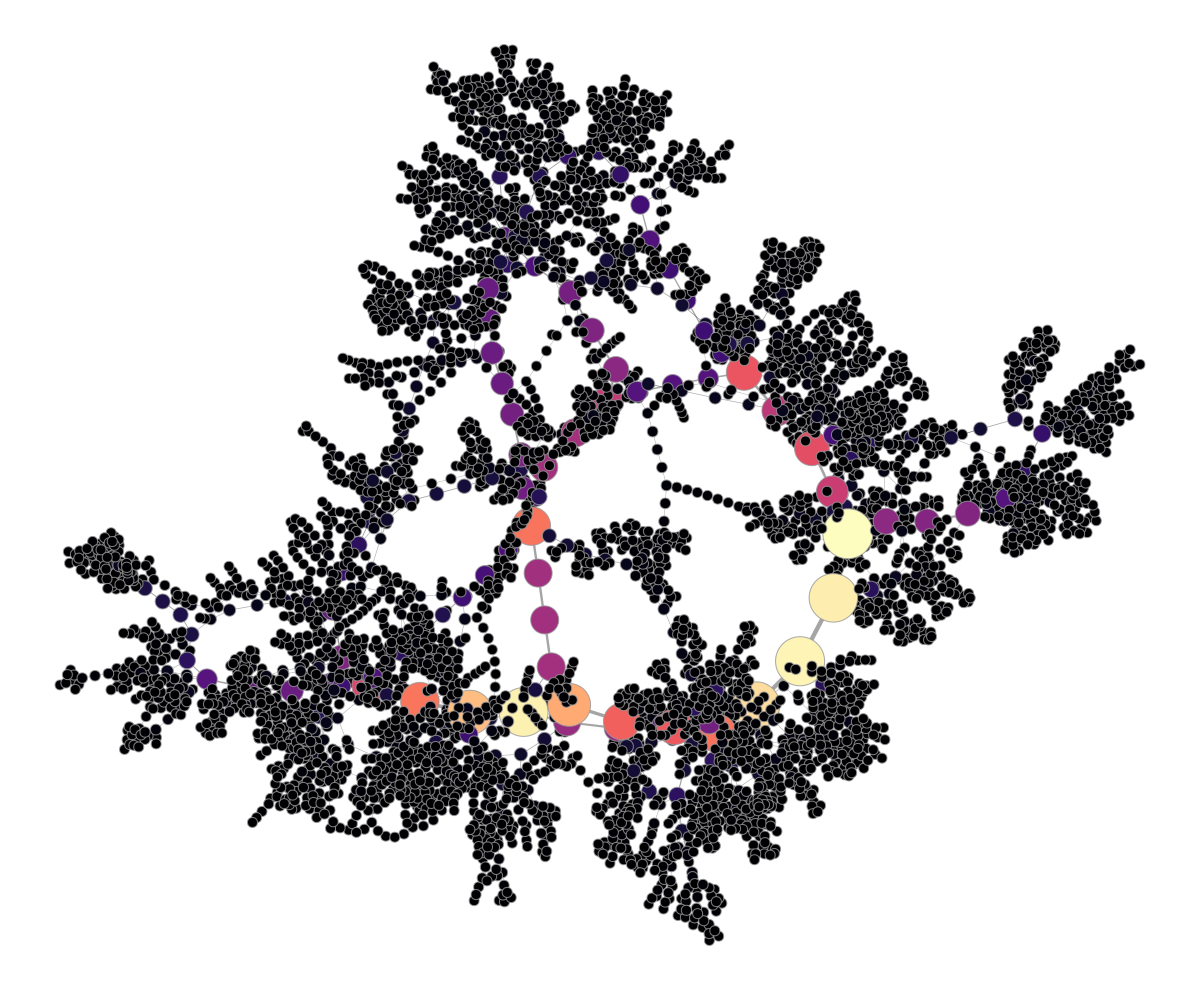

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7aaf7e600150, at 0x7ab11a514a50>

In [11]:
# Load power grid graph
ug = gt.GraphView(g, directed=False)

# Compute betweenness centrality (nodes and edges)
v_bet, e_bet = gt.betweenness(ug)

# Normalize values for visualization
v_bet.a = (v_bet.a - v_bet.a.min()) / (v_bet.a.max() - v_bet.a.min())
e_bet.a = (e_bet.a - e_bet.a.min()) / (e_bet.a.max() - e_bet.a.min())

# Node size proportional to betweenness
v_size = ug.new_vertex_property("double")
for v in ug.vertices():
    v_size[v] = 5 + 20 * v_bet[v]

# Edge thickness proportional to betweenness
e_width = ug.new_edge_property("double")
for e in ug.edges():
    e_width[e] = 0.2 + 2 * e_bet[e]

# Node color (hotter = more important)
v_color = v_bet

# Layout
pos = gt.sfdp_layout(ug)

# Draw graph
gt.graph_draw(
    ug,
    pos=pos,
    vertex_size=v_size,
    vertex_fill_color=v_color,
    edge_pen_width=e_width,
    edge_color=[0.3, 0.3, 0.3, 0.5]
)

# Problem 2: Small social graph visualization

In [12]:
X_knows = {
    'Mary': ['Peter', 'Albert', 'DavidF', 'Peter'],
    'Judy': ['Bob', 'Alan'],
    'Peter': ['Mary', 'DavidF', 'Jon'],
    'DavidF': ['Albert', 'Joseph', 'Peter', 'Mary'],
    'Jon': ['Peter', 'Joseph', 'DavidE'],
    'DavidE': ['Jon', 'Joseph', 'Albert'],
    'Joseph': ['DavidE', 'Jon', 'DavidF'],
    'Bob': ['Judy', 'Alan'],
    'Alan': ['Bob', 'Mary', 'Judy'],
    'Albert': ['DavidF', 'Mary', 'DavidE'],
}

**Task**: Create an undirected graph that represents the personal network above, remove parallel edges, and draw using a layout that resembles the tidy example as shown further below.

In [18]:
# Create UNDIRECTED graph
g = gt.Graph(directed=False)

# Add edges from relationship data
v_name = g.add_edge_list(
    ((n, k) for n in X_knows for k in X_knows[n]),
    hashed=True
)

# Save vertex names
g.vp["name"] = v_name

# Remove parallel (duplicate) edges
gt.remove_parallel_edges(g)

# Create layout
pos = gt.random_layout(g)

# Rotate layout to make it tidy
au.rotate_layout(pos, "Alan", "Mary", v_name)

In [21]:
# Vertex properties for drawing
vprops = dict(
    text=g.vp["name"],             # show name
    shape="circle",                 # node shape
    size=25,                        # node size
    fill_color=[0.8, 0.2, 0.2, 0.9], # red color
    pen_width=2                     # border thickness
)

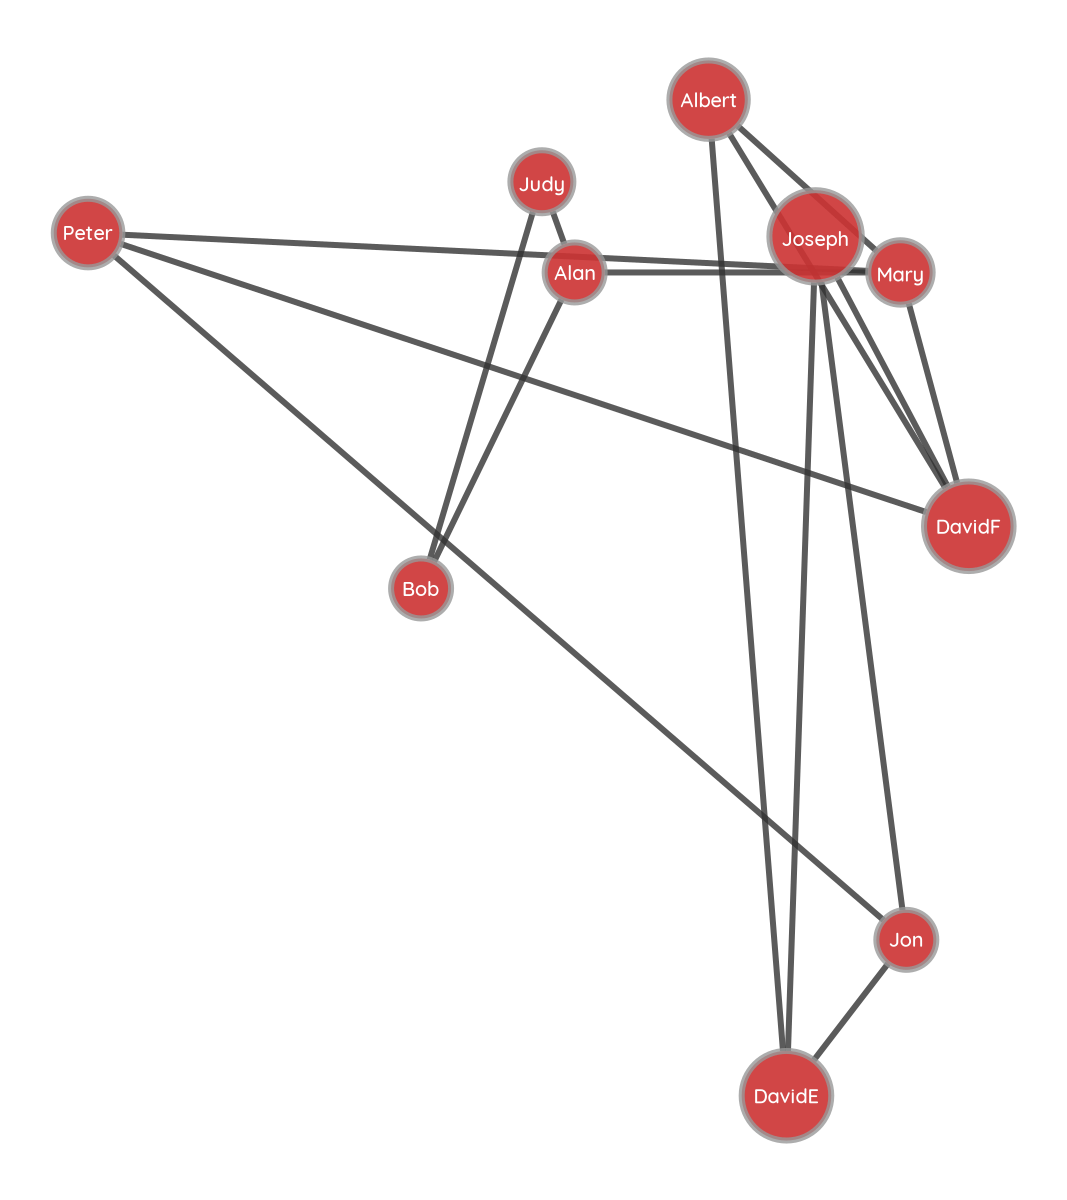

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7aaf6c95d110, at 0x7aaf7e601bd0>

In [23]:
gt.graph_draw(
    g,
    pos=pos,
    vertex_text=g.vp["name"],
    vertex_font_size=10,
    vertex_text_color="white",
    vertex_size=30,
    vertex_fill_color=[0.8,0.2,0.2,0.9],
    edge_color=[0.2,0.2,0.2,0.8]
)

After adjusting the code above you should be able to obtain a 'tidy' result like this.
![](graph.svg)

# Problem 3: Facebook graph analysis

For this question we will work with a real social graph of facebook friendship connections. Please download [`facebook_combined.txt` from SNAP](https://snap.stanford.edu/data/ego-Facebook.html), the Stanford Large Network Dataset Collection and create a `Graph` object with `graph-tool`. The dataset contains the ego networks of 10 facebook users, i.e. it contains the ego nodes, the friends of each of these facebook users, and the connections among those friends.

Goal below is to determine influencers among the users, based on a measure of centrality and not including the ego nodes themselves.

**Task 3a:** Load the dataset and create a drawing of the graph.

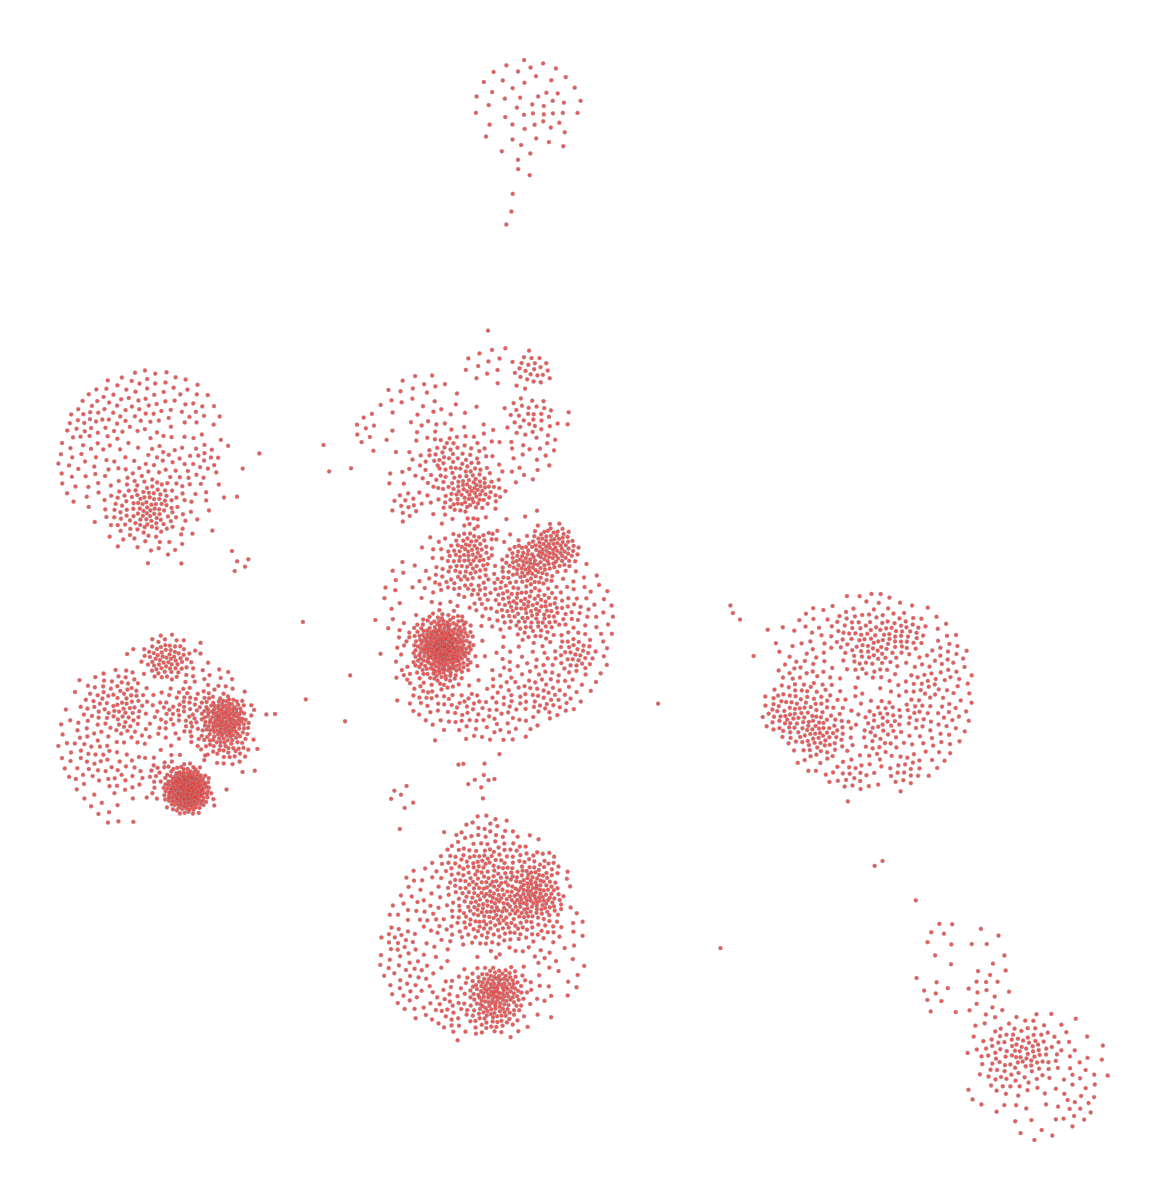

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7aaf66e53950, at 0x7aaf6722a4d0>

In [28]:
# Create empty undirected graph
g = gt.Graph(directed=False)

# Load edge list from file
g = gt.load_graph_from_csv(
    "facebook_combined.txt",   # file name
    directed=False,
    csv_options={"delimiter": " "}  # edges separated by space
)

# Compute layout (node positions)
pos = gt.sfdp_layout(g)   # fast layout for large graphs

# Draw graph
gt.graph_draw(
    g,
    pos=pos,
    vertex_size=2,                     # small nodes
    vertex_fill_color=[0.9, 0.2, 0.2, 0.8],
    edge_color=[1, 1, 1, 0.05],       # faint edges
    edge_pen_width=0.4
)

**Task 3b:** Calculate and show a histogram of pairwise distances among users. Internally, this distance would be computed for the shortest path of connections among any pair of users.

Use a log-scale of the frequencies to scale the histogram bars.

What is the diameter of this graph?

*Hint:* Calculating and drawing the histograms amounts to two lines of code using `gt` and `plt` modules.

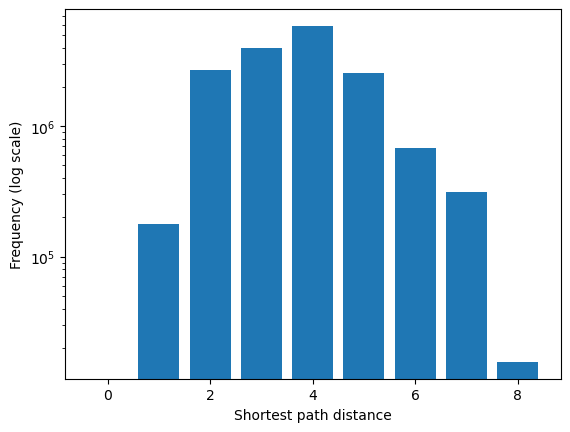

Graph diameter: 8


In [31]:
# Shortest path distance histogram
counts, bins = gt.distance_histogram(g)

# Plot histogram (log scale)
plt.bar(bins[:-1], counts)
plt.yscale('log')
plt.xlabel("Shortest path distance")
plt.ylabel("Frequency (log scale)")
plt.show()

# diameter of the graph
diameter = len(counts) - 1
print("Graph diameter:", diameter)

**Task 3c:** Determine influencers, i.e. people withing the ego network that are well connected among friends.

There are several steps to this analysis. First, remove the ego nodes. You can do this in an approximate way, simply by calculating a measure of influence of a user and removing the highest scoring nodes, assuming that these naturally are the ego nodes whose friends this network consists of.

Use `PageRank` as a measure of influence of a node.

*Step 1* - Create a drawing of a GraphView that only retains nodes with a `pagerank` $< 0.002$.

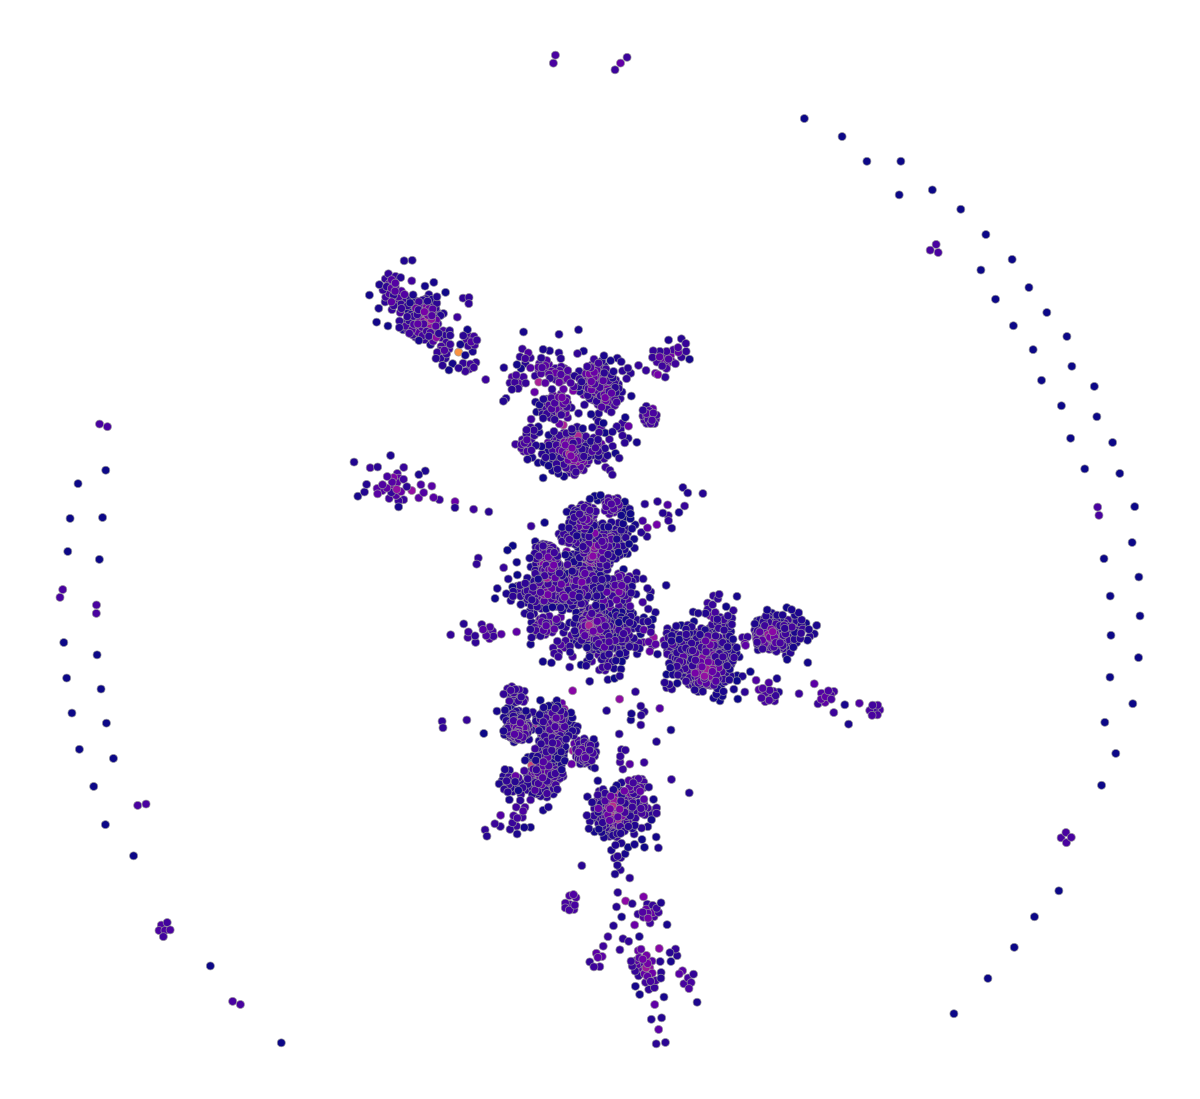

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7aaf66d84550, at 0x7aaf670c9590>

In [39]:
# Compute PageRank
pr = gt.pagerank(g)

# Filter low PageRank nodes
vfilt = g.new_vertex_property("bool")
for v in g.vertices():
    vfilt[v] = pr[v] < 0.002

# Filtered graph
gv = gt.GraphView(g, vfilt=vfilt)

# recompute PageRank on filtered graph
# We removed high-PageRank nodes (ego users).
# If we keep old PageRank, it still reflects the original full graph.
# That would be incorrect because the network structure has changed.
# So we compute PageRank again using only the remaining nodes.
# This shows influence inside the friend network only.
pr = gt.pagerank(gv)

# Normalize values
pr_vals = pr.copy()
pr_vals.a = (pr_vals.a - pr_vals.a.min()) / (pr_vals.a.max() - pr_vals.a.min())

# Layout
pos = gt.sfdp_layout(gv)

# Draw
gt.graph_draw(
    gv,
    pos=pos,
    vertex_size=4,
    vertex_fill_color=pr_vals,
    vcmap=plt.cm.plasma,
    edge_color=[1, 1, 1, 0.15]
)

*Step 2* - Only retain the largest connected component of this graph, i.e. create another [`GraphView`](https://graph-tool.skewed.de/static/doc/quickstart.html#graph-views) of only this largest component.

In [40]:
# Find connected components
# Each node gets a component ID
comp, hist = gt.label_components(gv)

# hist = size of each component
# Find the largest component ID
largest_comp_id = hist.argmax()

# Create filter: keep nodes only in largest component
v_lcc = gv.new_vertex_property("bool")
for v in gv.vertices():
    v_lcc[v] = (comp[v] == largest_comp_id)

# Create new GraphView with only largest connected component
gv_lcc = gt.GraphView(gv, vfilt=v_lcc)

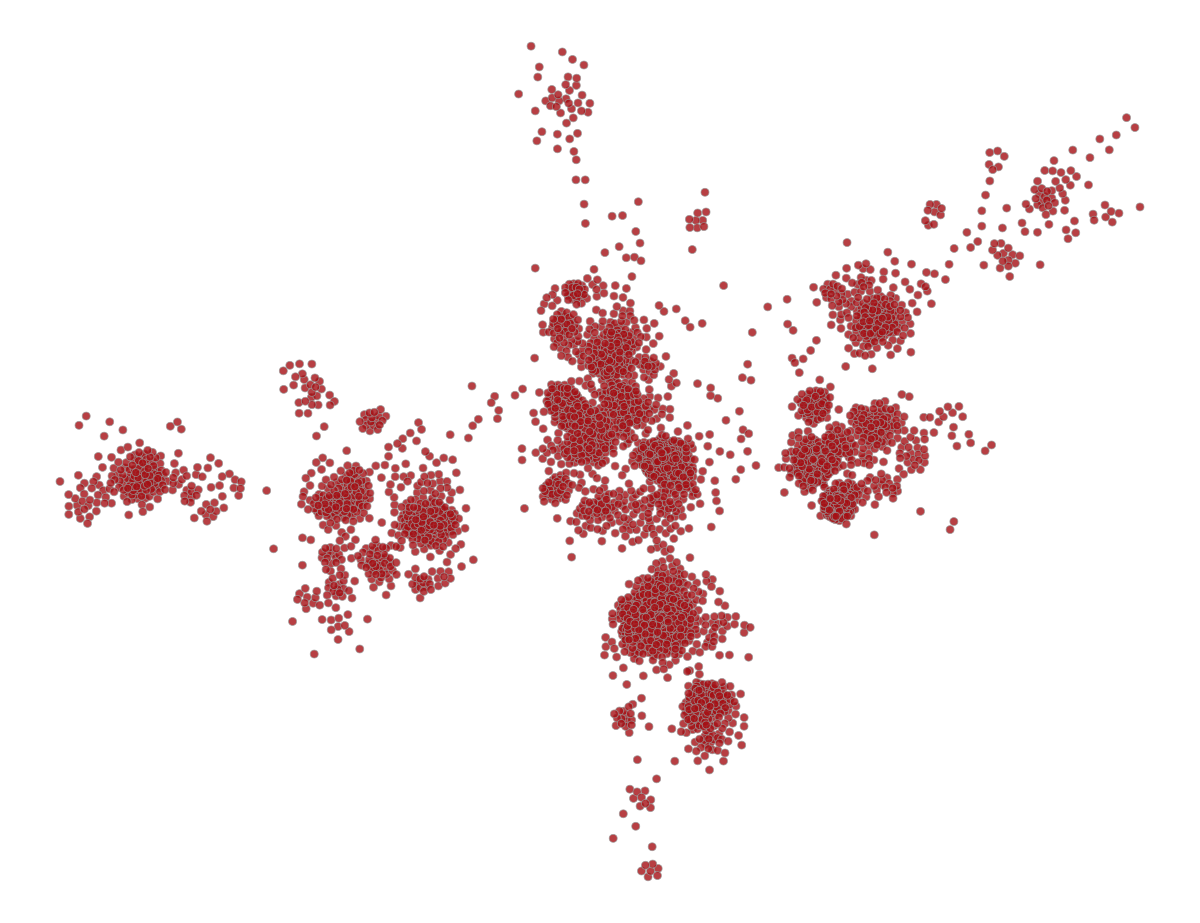

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7aaf6723b0d0, at 0x7aaf66e0ecd0>

In [41]:
pos = gt.sfdp_layout(gv_lcc)

gt.graph_draw(
    gv_lcc,
    pos=pos,
    vertex_size=4,
    edge_color=[1,1,1,0.15]
)

*Step 3* - Recalculate pagerank for each node, choose a threshold (e.g. 0.0005) above which only a small part of the users are selected. Create a drawing that emphasizes these users that play central roles among their friends.

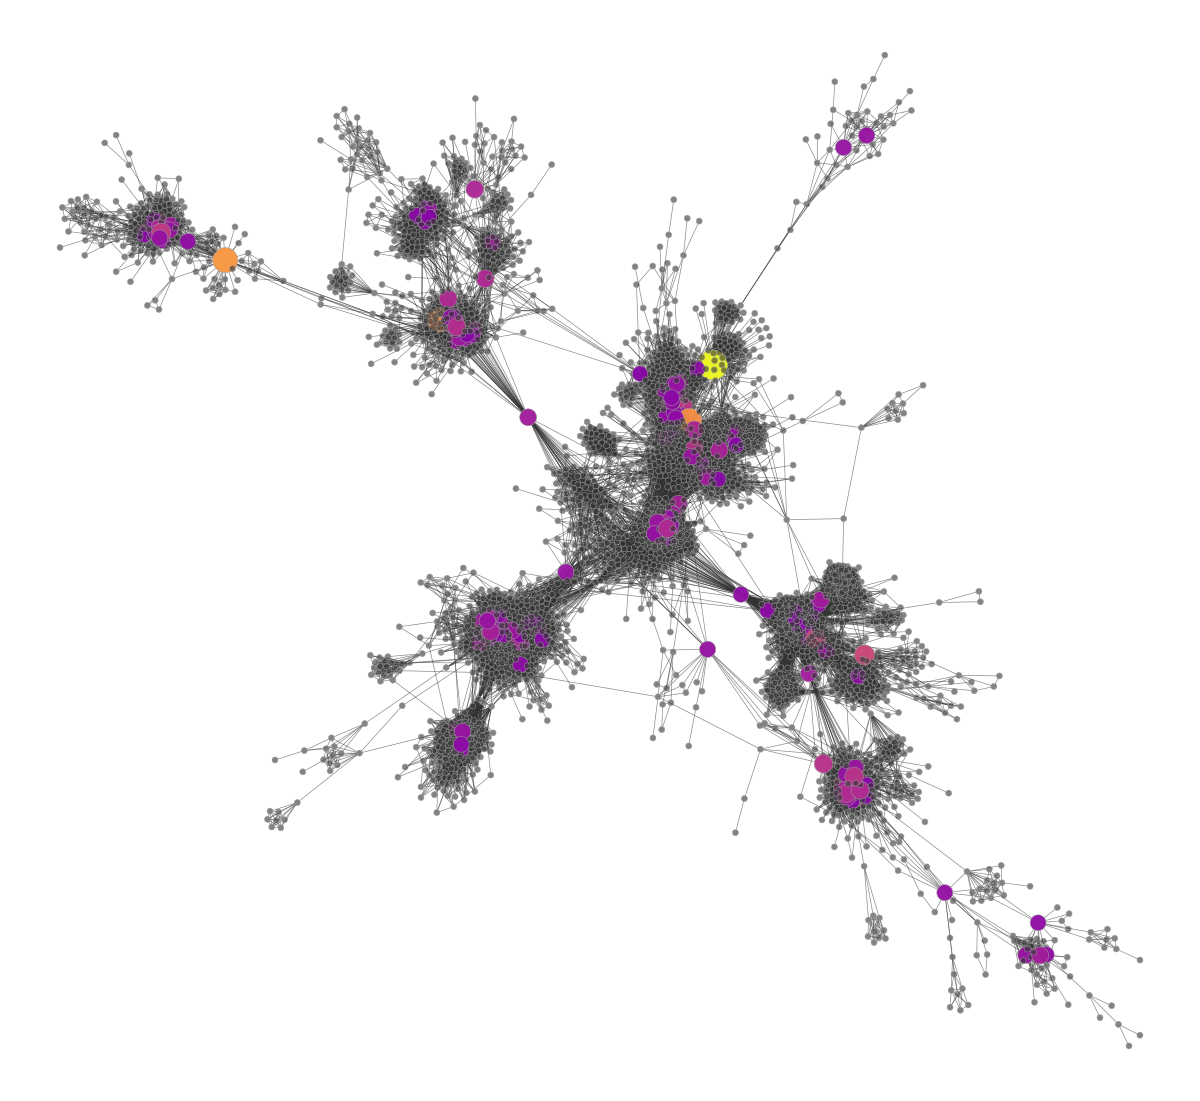

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7aaf6723b0d0, at 0x7aaf66d45090>

In [46]:
# PageRank on largest component
pr = gt.pagerank(gv_lcc)

threshold = 0.0005

# Normalize to 0~1
prn = pr.copy()
prn.a = (prn.a - prn.a.min()) / (prn.a.max() - prn.a.min())

# Vertex size
vsize = gv_lcc.new_vertex_property("double")

# Vertex color
vcolor = gv_lcc.new_vertex_property("vector<double>")

for v in gv_lcc.vertices():
    if pr[v] >= threshold:
        vsize[v] = 5 + 10 * prn[v]            # bigger if more influence
        c = plt.cm.plasma(prn[v])            # colorful
        vcolor[v] = [c[0], c[1], c[2], 0.95]
    else:
        vsize[v] = 3                         # small
        vcolor[v] = [0.2, 0.2, 0.2, 0.6]    # gray

# Layout
pos = gt.sfdp_layout(gv_lcc)

# Draw
gt.graph_draw(
    gv_lcc,
    pos=pos,
    vertex_size=vsize,
    vertex_fill_color=vcolor,
    edge_color=[0.2, 0.2, 0.2, 0.6]
)

# Environment setup details

[Setup instruction](https://graph-tool.skewed.de/installation.html) are available for most environments. To use the setup in the lab, see below.

We have prepared a `conda` environment in the lab that contains all modules required for this assignment. You can activate the environment as follows:

```
conda activate /usr/shared/CMPT/big-data/condaenv/nn11
or /usr/shared/CMPT/big-data/condaenv/nn11-deactivated
```

#### You might get an error
`CommandNotFoundError: Your shell has not been properly configured to use 'conda activate'.`
This happens, if you have not used conda before. To perform initialization once, we recommend the following steps:
```
cd /usr/shared/CMPT/big-data/miniforge3/bin
./conda init bash
./conda config --set auto_activate_base false
```
If you now restart your terminal shell or simply invoke a new one by typing `bash`, you can try activating the environment, again.

# Submission instructions
Please submit this A7.ipynb notebook
to Canvas with figures included.